## Implement The Linear Regression ML Models (Old models not in used)




### Topics
- Assumptions of Machine Learning(all ready done)
- Simple linear regression
- multiple linear regression
- variant of LR for RIDGE, LASSO ,ELASTICNET
- Measuring Performance metrics-Lost and Cost Function Model Evaluation Metrics ( MSE, MAE, RMSE)(R²-score, Adjusted R²-score)

variant of Linear models
- Polynomial Regression
- Linear Regression with OLS
- Linear Regression with SGD

- Under fitting and Overfitting
- Regularization ,Lasso & Ridge


# 1. assumption In Linear Regression

- Homoscedasticity

The variance of residuals should be approximately equal for all predicted values of the dependent variable.

- Normality - Errors are normally distributed

The residuals should be normally distributed.Linear relationship

There is a linear relationship between the dependent and independent variables

The error terms are normally distributed and the data do not contain outliers

- Independence of errors

The residual errors are independent of each other.

- No or low multicollinearity

There is no or little collinearity among input variables

#
https://www.geeksforgeeks.org/machine-learning/assumptions-of-linear-regression/
https://www.kdnuggets.com/2021/02/machine-learning-assumptions.html

![](https://media.geeksforgeeks.org/wp-content/uploads/20241025105428904464/Assumptions-of-Linear-Regression.webp)


<!-- #### MultiColiniarity
(optional)

- What it is

Multicollinearity occurs when independent variables are correlated, which can make it difficult to estimate each variable's relationship with the outcome variable.

- Why it's a problem

Multicollinearity can negatively impact model predictions on unseen data, and can make it difficult to explain the model's behavior.

- How to detect it

A correlation matrix can help identify multicollinearity, but a heatmap of correlations can be more intuitive. A variance inflation factor (VIF) can also be used to measure the amount of multicollinearity.

- How to address it

If multicollinearity is detected, it can be addressed by using a VIF to identify the correlated variables, and then removing or transforming those variables


from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['Price'] = data.target


#multicollinearity>> when one feature is explained by all other features
#when two features>> correlation
#more than two features>> vif, clustermap

sns.heatmap(df.corr(), annot = True, vmin = -1, vmax = 1)

#clustermap table shows group(cluster ) relationship
plt.figure(figsize = (5, 5))
sns.clustermap(df.corr(), vmin = -1, vmax =1, annot = True)

### What is the function of variance_inflation_factor?
Variance Inflation Factor (VIF)

A variance inflation factor (VIF) is a measure of the amount of multicollinearity in regression analysis. Multicollinearity exists when there is a correlation between multiple independent variables in a multiple regression model. This can adversely affect the regression results.


from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['Feature'] = df.columns
vif

vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]

df1 = df.copy()

df1.drop("Longitude", axis=1, inplace=True)
df1
vif = pd.DataFrame()
vif['Feature'] = df1.columns
vif["VIF"] = [variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]

vif

df1.drop("AveRooms", axis=1, inplace=True)
vif = pd.DataFrame()
vif['Feature'] = df1.columns
vif["VIF"] = [variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]

df1.drop("Latitude", axis=1, inplace=True)
vif = pd.DataFrame()
vif['Feature'] = df1.columns
vif["VIF"] = [variance_inflation_factor(df1.values, i) for i in range(len(df1.columns))]

Recursive Feature Elimination (RFE) is a feature selection method that iteratively removes features and trains a model on the remaining ones, evaluating its performance at each step. By repeatedly eliminating the least important features, RFE identifies the features that contribute most to the model's accuracy. It's a valuable tool for simplifying models and improving their efficiency.

#RFE >> recruseive feature elimination
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

from sklearn.feature_selection import RFE

rfe = RFE(estimator = LinearRegression(), n_features_to_select=6)

rfe.fit(X, y)

rfe.predict(X)

rfe.support_

X.columns

rfe.ranking_

 -->
rivision codes inside this markdown

## 2. Simple Linear Regression

- y=mx +c
single feature use

## 3. Multiple Linear Regression

- multiple  feature/X use
- y =M1x1 +M2x2 + M3x3 + MnXn +c

## 4. Ridge Regression

In [1]:
# import
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,LabelEncoder ,StandardScaler
from sklearn.model_selection import train_test_split # train test split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import pandas as pd
df = pd.read_csv(r"clean_data_EDA.csv")

df.drop(columns=['availability','society','price_per_sqft'],axis=1,inplace=True)

X = df.drop(columns=["price"])
print(X.columns)
y = df["price"]

# train test split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# task 1 transform applying --> columns transform
columns_trans = ColumnTransformer(
    [('onehot_location', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['location']),
     ('onehot_area_type', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ["area_type"]),
     ('scaler', StandardScaler(), ["total_sqft", "bath"]),
     ],
    remainder='passthrough')

Index(['area_type', 'location', 'size', 'total_sqft', 'bath', 'balcony'], dtype='object')


In [ ]:
# pipe_lr = make_pipeline(columns_trans, lr)

# Ridge Regression
from sklearn.linear_model import Ridge
pipe_ridge = make_pipeline(columns_trans, Ridge(alpha=1.0))

pipe_ridge.fit(x_train, y_train) 

y_pred_ridge = pipe_ridge.predict(x_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge Regression MSE: {mse_ridge:.4f}")
print(r2_score(y_test, y_pred_ridge))

In [48]:
# Lasso Regression
from sklearn.linear_model import Lasso
pipe_lasso = make_pipeline(columns_trans, Lasso(alpha=0.1))

pipe_lasso.fit(x_train, y_train)
y_pred_lasso = pipe_lasso.predict(x_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f"Lasso Regression MSE: {mse_lasso:.4f}")
print(r2_score(y_test, y_pred_lasso))

Lasso Regression MSE: 15828.9968
0.32128792826882624


In [49]:
# Elastic Net Regression
from sklearn.linear_model import ElasticNet
pipe_elastic_net = make_pipeline(columns_trans, ElasticNet(alpha=0.1, l1_ratio=0.5))

pipe_elastic_net.fit(x_train, y_train)
y_pred_elastic_net = pipe_elastic_net.predict(x_test)
mse_elastic_net = mean_squared_error(y_test, y_pred_elastic_net)

print(f"Elastic Net Regression MSE: {mse_elastic_net:.4f}")
print(r2_score(y_test, y_pred_elastic_net))

Elastic Net Regression MSE: 18645.7019
0.20051389731807645


### 3. polynomial Regression

In [ ]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9*X + 2 + np.random.randn(200, 1)
#equation used -> y = 0.8x^2 + 0.9x + 2
#visualize the data
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [6]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

0.27328491589372617


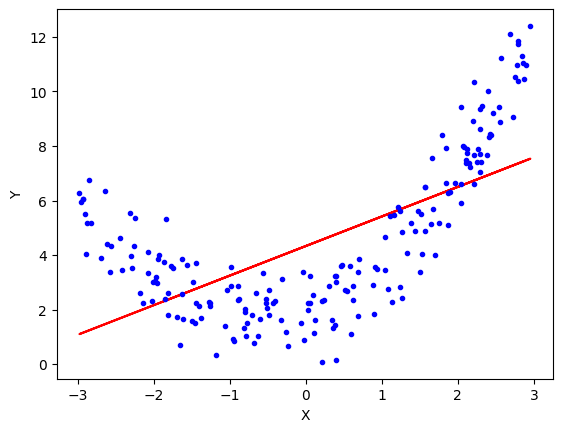

In [7]:
# Simple linear regression
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print(r2_score(y_test, y_pred))

plt.plot(x_train, lr.predict(x_train), color="r")
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [8]:
# polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
#applying polynomial regression degree 2
poly = PolynomialFeatures(degree=2, include_bias=True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)
#include bias parameter
lr = LinearRegression()
lr.fit(x_train_trans, y_train)
y_pred = lr.predict(x_test_trans)
print(r2_score(y_test, y_pred))

print(lr.coef_)
print(lr.intercept_)

0.8490052178395535
[[0.         0.94619599 0.76885348]]
[2.01186341]


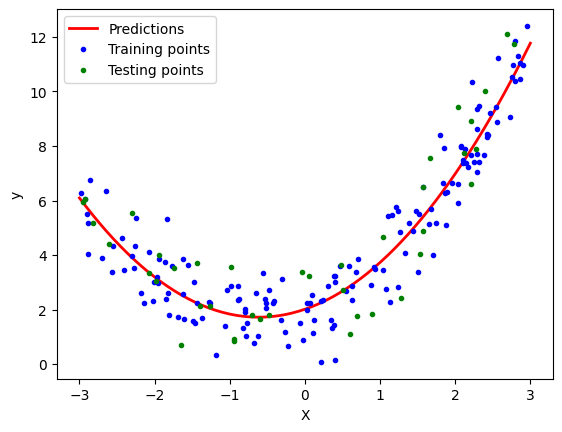

In [9]:
# image show
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## ⚙️ **SGD: Stochastic Gradient Descent**

**SGD (Stochastic Gradient Descent)** is an **optimization algorithm** used to *find the best weights* for models like Linear Regression.

Normally, in Linear Regression, you could compute the exact solution using a formula (called the **Normal Equation**).
But with **large datasets** or **many features**, that becomes slow or memory-intensive.

Instead, we use **SGD**, which updates the model step-by-step using small portions of data (even one sample at a time).

---

### 🔢 **How it works**

1. Start with random weights.
2. Pick one (or a small batch of) training sample(s).
3. Compute the **prediction** and the **error** (difference between prediction and actual value).
4. Adjust the weights slightly in the direction that **reduces the error** (using the gradient).
5. Repeat for many epochs (passes through the dataset).

The update rule:
wi:=wi-∂Loss/η∂wi

Where:

* η = learning rate (controls how big each step is)
* (∂Loss/∂wi ) = gradient (slope of the loss function)

---

## 📈 **So: “Linear Regression with SGD” means**

> Training a **linear regression model** using the **stochastic gradient descent** optimization method instead of the closed-form normal equation.

---

### 🧠 **Example in Python (using scikit-learn)**
---


## 4. Linear Regression with SGD

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import SGDRegressor
# 1. Load data
data = fetch_california_housing()
X, y = data.data, data.target
# 2. Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 4. Stochastic Gradient Descent
sgd = SGDRegressor(loss='squared_error', penalty=None, learning_rate='constant', eta0=0.01, max_iter=1000, random_state=42)
sgd.fit(X_train, y_train)
pred_sgd = sgd.predict(X_test)
mse_sgd = mean_squared_error(y_test, pred_sgd)

print(f"Stochastic Gradient Descent (SGD) : {mse_sgd:.4f}")
print(r2_score(y_test, pred_sgd))

Stochastic Gradient Descent (SGD) : 23531214787431355928648089600000.0000
-1.7957153208015861e+31


# 5.Linear Regression with OLS


## 📘 **Linear Regression with Ordinary Least Squares (OLS)**

### 🔹 1. **Concept**

**Linear Regression** is one of the simplest and most widely used statistical models in Machine Learning.
It models the relationship between one or more independent variables (features) and a dependent variable (target) by fitting a **straight line (or hyperplane)** through the data.

---


In [ ]:
import numpy as np

# Sample Data
# X: Independent variable(s)
# y: Dependent variable
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 5])

print("X:", X)
print("y:", y)

# Add a column of ones to include the intercept term
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape -> (n_samples, 2)

# OLS Formula: β = (XᵀX)⁻¹ Xᵀy
beta_hat = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Coefficients
intercept, slope = beta_hat
print("Intercept:", intercept)
print("Slope:", slope)

# Predictions
y_pred = X_b.dot(beta_hat)

# Model Evaluation (R² Score)
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r2 = 1 - (ss_res / ss_total)

print("Predictions:", y_pred)
print("R² Score:", r2)


X: [1 2 3 4 5]
y: [2 4 5 4 5]
Intercept: 2.2000000000000046
Slope: 0.6000000000000002
Predictions: [2.8 3.4 4.  4.6 5.2]
R² Score: 0.6000000000000001


  
### 🔹 2. **Model Equation**

For **multiple linear regression**:


---

### 🔹 3. **Ordinary Least Squares (OLS)**

OLS is the **method used to estimate the coefficients ((\beta_i))** of the regression equation.

It finds the values of (\beta) that **minimize the sum of squared residuals** (differences between actual and predicted values):


Minimize i=1∑n​(yi​−yi​^​)2
or equivalently in matrix form:

[
\hat{\beta} = (X^T X)^{-1} X^T y
]

Where:

* ( X ) = matrix of input features (including a column of 1s for intercept)
* ( y ) = vector of outputs
* ( \hat{\beta} ) = estimated coefficients

---

### 🔹 4. **Steps to Perform OLS Regression**

1. Collect data ((X, y))
2. Add an intercept term (column of ones)
3. Compute coefficients using
   [
   \hat{\beta} = (X^T X)^{-1} X^T y
   ]
4. Predict outputs:
   [
   \hat{y} = X\hat{\beta}
   ]
5. Evaluate the model using metrics like ( R^2 ), RMSE, MAE, etc.

---

### 🔹 5. **Assumptions of Linear Regression (OLS)**

OLS relies on several assumptions:

| **Assumption**           | **Meaning**                            | **Example of Violation**                   |
| ------------------------ | -------------------------------------- | ------------------------------------------ |
| **Linearity**            | Relationship between X and y is linear | Using a straight line to model curved data |
| **Independence**         | Observations are independent           | Time series data with autocorrelation      |
| **Homoscedasticity**     | Constant variance of errors            | Variance of residuals increases with X     |
| **Normality of Errors**  | Residuals are normally distributed     | Heavy-tailed error distribution            |
| **No Multicollinearity** | Predictors are not highly correlated   | Two features are nearly identical          |

---

### 🔹 6. **Model Evaluation Metrics**

* **R² (Coefficient of Determination)**:
  [
  R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
  ]
  Measures how well the regression line fits the data.

* **Mean Squared Error (MSE):**
  [
  MSE = \frac{1}{n} \sum (y_i - \hat{y_i})^2
  ]

* **Root Mean Squared Error (RMSE):**
  [
  RMSE = \sqrt{MSE}
  ]

---

### 🔹 7. **Advantages**

✅ Simple and easy to interpret
✅ Computationally efficient
✅ Works well for linearly related data

---

### 🔹 8. **Limitations**

❌ Sensitive to outliers
❌ Performs poorly on non-linear relationships
❌ Assumes all assumptions (e.g., homoscedasticity, independence) are satisfied

---

### 🔹 9. **Example (Simple Linear Regression)**

[
y = 2 + 3x + \epsilon
]

If data is:

| x | y  |
| - | -- |
| 1 | 5  |
| 2 | 8  |
| 3 | 11 |

The OLS method would estimate:
[
beta_0 = 2, beta_1 = 3
]
so predictions are ( y = 2 + 3x ).

---


## GO with Logistic Regression